# 04 - Error Analysis (Oracle Ceiling, Rule Recovery, Failure-Mode Gaps)

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

from src.oracle import oracle_predict, oracle_rule_breakdown
from src.features import numeric_cols_for_scenario_c
from src.preprocessing import NUMERIC_COLS, CATEGORICAL_COLS

pd.set_option("display.max_columns", 30)
FIGURES_DIR = REPO_ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## Load test data and trained models

In [2]:
splits = joblib.load(REPO_ROOT / "results" / "feature_splits.joblib")

y_test = splits["y_test"]
modes_test = splits["modes_test"]
X_test_A = splits["X_test_A"]
X_test_B = splits["X_test_B"]
X_test_C = splits["X_test_C"]

test_features = {"A": X_test_A, "B": X_test_B, "C": X_test_C}

MODELS_DIR = REPO_ROOT / "models"
models = {}
for scenario in test_features:
    for model_key in ["logreg", "tree", "knn"]:
        path = MODELS_DIR / f"{model_key}_{scenario}.joblib"
        models[(scenario, model_key)] = joblib.load(path)

sorted(models.keys())


[('A', 'knn'),
 ('A', 'logreg'),
 ('A', 'tree'),
 ('B', 'knn'),
 ('B', 'logreg'),
 ('B', 'tree'),
 ('C', 'knn'),
 ('C', 'logreg'),
 ('C', 'tree')]

## Oracle ceiling on the test set

In [3]:
oracle_pred = oracle_predict(X_test_A)

oracle_row = {
    "precision": precision_score(y_test, oracle_pred, zero_division=0),
    "recall": recall_score(y_test, oracle_pred, zero_division=0),
    "f1": f1_score(y_test, oracle_pred, zero_division=0),
}
oracle_metrics = pd.DataFrame([oracle_row], index=["oracle"])
oracle_metrics


,precision,recall,f1
oracle,1.0,0.838235,0.912


In [4]:
confusion_matrix(y_test, oracle_pred)


array([[1932,    0],
       [  11,   57]])

## Gap to the oracle, every model and scenario

In [5]:
results_df = pd.read_csv(REPO_ROOT / "results" / "metrics_scenarios.csv")

gap_rows = []
for (scenario, model_key), model in models.items():
    X_test = test_features[scenario]
    y_pred = model.predict(X_test)
    row = results_df[(results_df["scenario"] == scenario) & (results_df["model"] == model_key)].iloc[0]
    gap_rows.append({
        "scenario": scenario,
        "model": model_key,
        "recall": row["recall"],
        "oracle_recall": oracle_row["recall"],
        "recall_gap": oracle_row["recall"] - row["recall"],
        "agreement_with_oracle": float((y_pred == oracle_pred).mean()),
    })

gap_df = pd.DataFrame(gap_rows).sort_values(["scenario", "model"]).reset_index(drop=True)
gap_df


,scenario,model,recall,oracle_recall,recall_gap,agreement_with_oracle
0,A,knn,0.147059,0.838235,0.691176,0.9760
1,A,logreg,0.808824,0.838235,0.029412,0.8255
2,A,tree,0.838235,0.838235,0.000000,0.9585
3,B,knn,0.250000,0.838235,0.588235,0.9795
4,B,logreg,0.926471,0.838235,-0.088235,0.8815
5,B,tree,0.867647,0.838235,-0.029412,0.9405
6,C,knn,0.294118,0.838235,0.544118,0.9810
7,C,logreg,0.882353,0.838235,-0.044118,0.8495
8,C,tree,0.926471,0.838235,-0.088235,0.9480


## Recall gap by failure mode, oracle vs the best model per scenario

In [6]:
oracle_breakdown = oracle_rule_breakdown(X_test_A)

def recall_per_mode_for_pred(y_pred, modes_test):
    rows = []
    for mode in modes_test.columns:
        mask = modes_test[mode] == 1
        if mask.sum() == 0:
            rows.append({"mode": mode, "n": 0, "recall": np.nan})
            continue
        caught = np.asarray(y_pred)[mask.values] == 1
        rows.append({"mode": mode, "n": int(mask.sum()), "recall": float(caught.mean())})
    return pd.DataFrame(rows)

oracle_mode_recall = recall_per_mode_for_pred(oracle_pred, modes_test)
oracle_mode_recall["source"] = "oracle"

best_per_scenario = results_df.loc[results_df.groupby("scenario")["f1"].idxmax()]
best_mode_rows = []
for _, row in best_per_scenario.iterrows():
    scenario, model_key = row["scenario"], row["model"]
    model = models[(scenario, model_key)]
    y_pred = model.predict(test_features[scenario])
    df_mode = recall_per_mode_for_pred(y_pred, modes_test)
    df_mode["source"] = f"{model_key}_{scenario}"
    best_mode_rows.append(df_mode)

mode_gap_df = pd.concat([oracle_mode_recall] + best_mode_rows, ignore_index=True)
mode_gap_df.pivot_table(index="source", columns="mode", values="recall")


mode,HDF,OSF,PWF,RNF,TWF
source,,,,,
oracle,1.000000,1.0,1.000000,0.00,0.1
tree_A,0.965517,1.0,0.923077,0.50,0.3
tree_B,0.931034,1.0,0.923077,0.25,0.6
tree_C,1.000000,1.0,1.000000,0.25,0.7


## Decision tree, scenario C: learned thresholds vs the documented rules

In [7]:
tree_model = models[("C", "tree")]
preprocessor = tree_model.named_steps["prep"]
tree_clf = tree_model.named_steps["clf"]

feature_names = preprocessor.get_feature_names_out()
print(export_text(tree_clf, feature_names=list(feature_names), max_depth=4))


|--- num__Rotational speed [rpm] <= 1386.50
|   |--- num__temp_diff <= 8.65
|   |   |--- num__Rotational speed [rpm] <= 1380.00
|   |   |   |--- num__temp_diff <= 8.55
|   |   |   |   |--- num__wear_x_torque <= 1229.15
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- num__wear_x_torque >  1229.15
|   |   |   |   |   |--- class: 1
|   |   |   |--- num__temp_diff >  8.55
|   |   |   |   |--- num__Air temperature [K] <= 302.15
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- num__Air temperature [K] >  302.15
|   |   |   |   |   |--- class: 1
|   |   |--- num__Rotational speed [rpm] >  1380.00
|   |   |   |--- class: 1
|   |--- num__temp_diff >  8.65
|   |   |--- num__wear_x_torque <= 11013.60
|   |   |   |--- num__power_W <= 9005.23
|   |   |   |   |--- num__Tool wear [min] <= 202.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__Tool wear [min] >  202.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- num__power_W >  9005.23
|   |   |   |   |--- class: 1
|   

In [8]:
true_thresholds = pd.DataFrame([
    {"rule": "HDF", "quantity": "temp_diff", "threshold": 8.6, "comparison": "<"},
    {"rule": "HDF", "quantity": "Rotational speed [rpm]", "threshold": 1380, "comparison": "<"},
    {"rule": "PWF", "quantity": "power_W", "threshold": 3500, "comparison": "<"},
    {"rule": "PWF", "quantity": "power_W", "threshold": 9000, "comparison": ">"},
    {"rule": "OSF", "quantity": "wear_x_torque (Type L)", "threshold": 11000, "comparison": ">"},
    {"rule": "OSF", "quantity": "wear_x_torque (Type M)", "threshold": 12000, "comparison": ">"},
    {"rule": "OSF", "quantity": "wear_x_torque (Type H)", "threshold": 13000, "comparison": ">"},
])
true_thresholds


,rule,quantity,threshold,comparison
0,HDF,temp_diff,8.6,<
1,HDF,Rotational speed [rpm],1380.0,<
2,PWF,power_W,3500.0,<
3,PWF,power_W,9000.0,>
4,OSF,wear_x_torque (Type L),11000.0,>
5,OSF,wear_x_torque (Type M),12000.0,>
6,OSF,wear_x_torque (Type H),13000.0,>


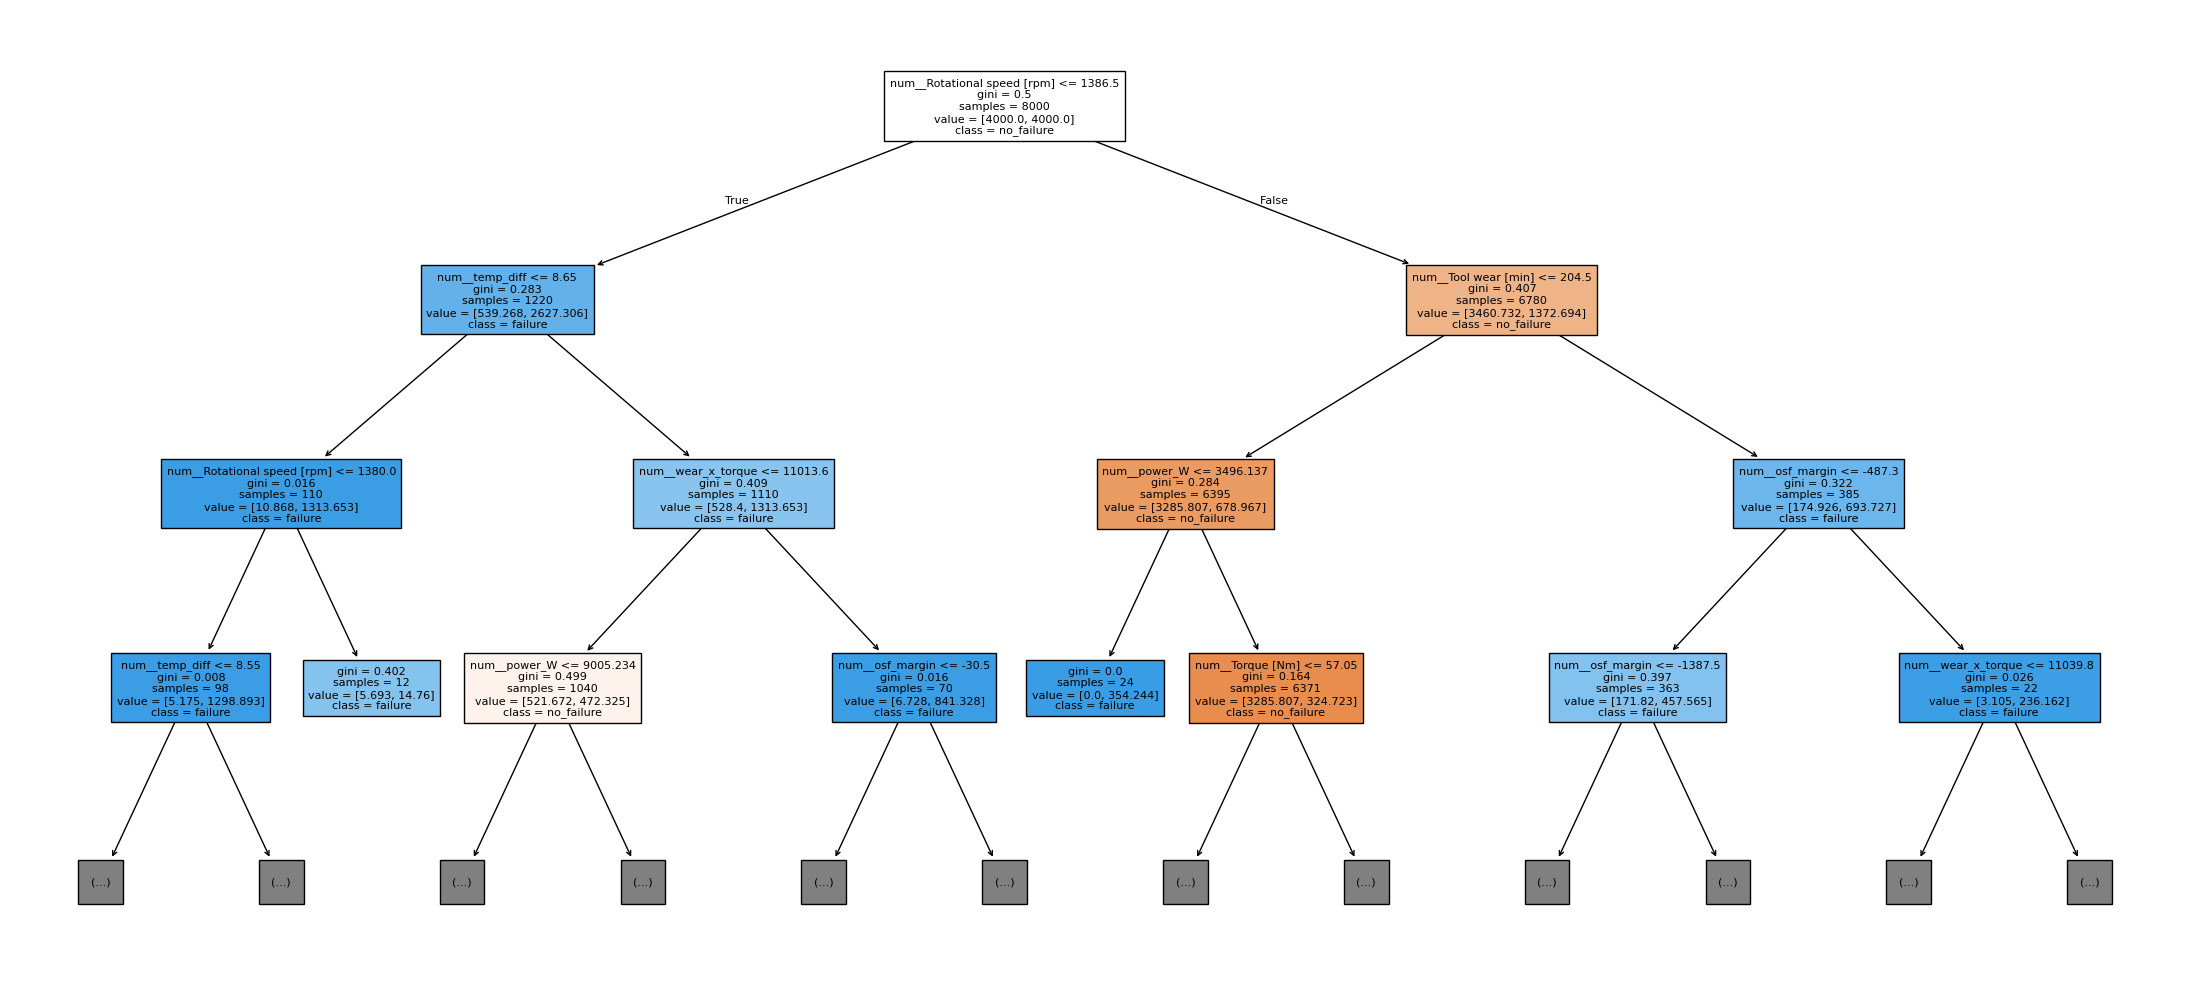

In [9]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    tree_clf,
    feature_names=list(feature_names),
    class_names=["no_failure", "failure"],
    filled=True,
    max_depth=3,
    fontsize=8,
    ax=ax,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "tree_scenario_C.png", dpi=150)
plt.show()


## Save error analysis outputs

In [10]:
RESULTS_DIR = REPO_ROOT / "results"

oracle_metrics.to_csv(RESULTS_DIR / "oracle_metrics.csv")
gap_df.to_csv(RESULTS_DIR / "oracle_gap_by_model.csv", index=False)
mode_gap_df.to_csv(RESULTS_DIR / "oracle_gap_by_mode.csv", index=False)

sorted(p.name for p in RESULTS_DIR.glob("*.csv"))


['metrics_scenarios.csv',
 'oracle_gap_by_mode.csv',
 'oracle_gap_by_model.csv',
 'oracle_metrics.csv',
 'recall_per_mode.csv']